## Importing packages and defining functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
def KenneyLau(GS,P):
    H = []
    F = []
    HF = []
    for i in range(len(GS)):
        if GS[i] <= (max(GS)/4):
            D = GS[i]
            D4 = D * 4
            D4loc = np.argmax(GS >= D4)
            P1 = P[i]
            P2 = P[D4loc]
            a = (P2 - P1)/100
            b = P1/100
            H.append(a)
            F.append(b)
            HF.append(a/b)
    HF_min = float(min(HF))
    H = [float(x) for x in H]
    F = [float(x) for x in F]
    HF = [float(x) for x in HF]
    return HF_min, H, F, HF

## Upload PSD

Upload your PSD as .txt file with grain size (mm) in column 1 and percentage pass (%) in column 2 - See "TestSoilA.txt" for correct format. Do not use headers. An easy way to do this is to copy two columns from excel directly into a notepad file.

Enter the filename in the box below

In [3]:
filename = "TestSoilC.txt"

In [4]:
PSD = np.loadtxt(open(filename,'rt').readlines(), delimiter='\t')
GS = PSD[:,0]
P = PSD[:,1]
#artificial sieve sizes in between actual sieve sizes are created using interpolation to allow KL calculation and obtaining characteristic grain sizes
#to speed up the code and because of the log scale, smaller sieve steps are used below a split point grainsize, and larger after.

#below split_point grain size (mm) artificial sieve sizes will increase in steps of step_1 mm, 
#above split_point, artificial sieve sizes will increase in steps of step_2 mm. Adjust these values to match the PSDs in the following box
split_point = 0.5  
step_1 = 0.001
step_2 = 0.1
PSD_func =  interp1d(np.log(GS),P,fill_value='extrapolate') #adds artificial sieve sizes in between actual values to fill out the data and allow grainsizes to be interpolated
new_GS = np.append(np.arange(min(GS),0.5,step_1),np.arange(0.5,max(GS), step_2)) #split up to reduce runtime, you can mess with steps to optimise for your PSD
new_P = PSD_func(np.log(new_GS))

Check that your original PSD and the interpolated PSD match visually. If they do not, vary `split_point`, `step_1` and `step_2` above

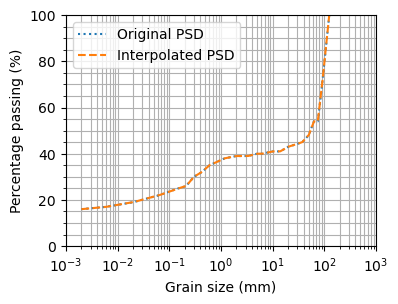

In [7]:
plt.figure(figsize = (4,3))
plt.semilogx(GS,P, label = "Original PSD",linestyle=":")
plt.semilogx(new_GS,new_P, label = "Interpolated PSD",linestyle="--")
plt.ylim(0,100)
plt.xlim(1e-3,1000)
plt.minorticks_on()
plt.grid(which = "both")
plt.legend()
plt.xlabel("Grain size (mm)")
plt.ylabel("Percentage passing (%)");

## Kenney and Lau (1985) calculation

In [8]:
HF_min, H, F, HF = KenneyLau(new_GS,new_P)

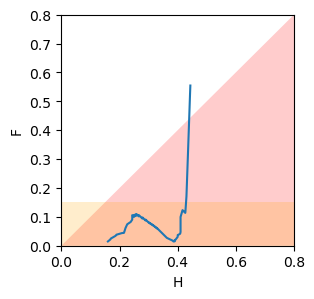

In [9]:
plt.figure(figsize = (3,3))
plt.plot(F,H)
plt.fill_between((0,1),(0,1), alpha = 0.2, facecolor = "red")
plt.fill_between((0,0.8),(0.15,0.15),alpha = 0.2, facecolor = "orange")
plt.ylim(0,0.8)
plt.xlim(0,0.8)
plt.xlabel("H")
plt.ylabel("F");


In [10]:
print(f"The minimum H/F value is {HF_min:.3f}")
PSD_split = H[HF.index(HF_min)]
print(f"The split between the finer and courser fraction occurs at {PSD_split:.3f} mm")
finer_fraction = new_P[np.where(np.isclose(new_GS, PSD_split,atol=1e-03))[0][0]]
print(f"The finer fraction is {finer_fraction:.1f}%")

The minimum H/F value is 0.038
The split between the finer and courser fraction occurs at 0.015 mm
The finer fraction is 18.4%
